# Example 3: 
## Multiple WEC-Farm with load curve
This notebook demonstrates applying Multiple WEC-Farm configurations:
- Setting up a grid system with 3 WEC farms
- Reviewing Load curve
- Running time-domain simulations
- Analyzing WEC performance and grid impact

This example uses the IEEE 39 case system with wave energy converters and load curve.

In [1]:
import wecgrid

example3 = wecgrid.Engine()

example3.case("./grid_models/IEEE_39_bus.raw")
example3.load(["pypsa","psse"])

INFO:pssepath.core:PSSBIN already in path, adding PSSBIN from pssepath skipped.


PSS®E software initialized


---

## Apply the WEC-Farms

Lets create 3 WEC Farm. Two of the Farms will have 10 RM3 devices each, while the fourth will have 10 LUPA devices. The LUPA simulation data was pulled from the pre-loaded WEC-Grid database found here. Specifics about the LUPA run can be found in the documentation.

In [2]:
#Information about the wec-sim runs in database can accessed using 
example3.database.wecsim_runs()

,wec_sim_id,model_type,sim_duration_sec,delta_time,wave_height_m,wave_period_sec,wave_spectrum,wave_class,wave_seed,simulation_hash,created_at
0,2,LUPA,86400.0,0.1,2.5,8.0,PM,irregular,8,LUPA_2.5m_8.0s_8,2025-08-19 19:59:49
1,1,RM3,86400.0,0.1,2.5,8.0,PM,irregular,94,RM3_2.5m_8.0s_94,2025-08-19 19:45:01


In [3]:
###### RM3 Farm 
example3.apply_wec(
   farm_name = "RM3-FARM",
   size = 10, 
   wec_sim_id = 1,
   bus_location=40, # create a new bus for farm  
   connecting_bus = 39, 
)

###### RM3 Farm 2
example3.apply_wec(
   farm_name = "RM3-FARM2",
   size = 10, 
   wec_sim_id = 1,
   bus_location=41, # create a new bus for farm  
   connecting_bus = 25, 
)


###### LUPA Farm 
example3.apply_wec(
   farm_name = "LUPA-FARM",
   size = 10, 
   wec_sim_id = 2, # LUPA
   bus_location=42, # create a new bus for farm  
   connecting_bus = 29, # Connect to bus 1 or swing bus
)


WEC Farm added: RM3-FARM
WEC Farm added: RM3-FARM2
WEC Farm added: LUPA-FARM


---
## Review WEC-Farm / WEC-Device Data

In [4]:
# Farm Data
WECFarms = example3.wec_farms # list 

RM3_Farm_1 = WECFarms[0]
LUPA_Farm_1 = WECFarms[1]
print(RM3_Farm_1)
print(LUPA_Farm_1)

WECFarm:
        ├─ name: 'RM3-FARM'
        ├─ size: 10
        ├─ model: 'RM3'
        ├─ bus_location: 40
        ├─ connecting_bus: 39
        └─ sim_id: 1

        Base: 100.0 MVA

    
WECFarm:
        ├─ name: 'RM3-FARM2'
        ├─ size: 10
        ├─ model: 'RM3'
        ├─ bus_location: 41
        ├─ connecting_bus: 25
        └─ sim_id: 1

        Base: 100.0 MVA

    


WECDevice:
    ├─ name: 'RM3_1_0'
    ├─ model: 'RM3'
    ├─ bus_location: 40
    ├─ sim_id: 1
    └─ rows: 288
    
                     time         p    q       eta
snapshots                                         
2025-09-06 00:00:00   300  0.000135  0.0 -0.003430
2025-09-06 00:05:00   600  0.000135  0.0 -0.003430
2025-09-06 00:10:00   900  0.000197  0.0  0.002427
2025-09-06 00:15:00  1200  0.000192  0.0  0.001373
2025-09-06 00:20:00  1500  0.000151  0.0  0.000987


<AxesSubplot:title={'center':'Wave Elevation - RM3'}, xlabel='time(s)', ylabel='meters'>

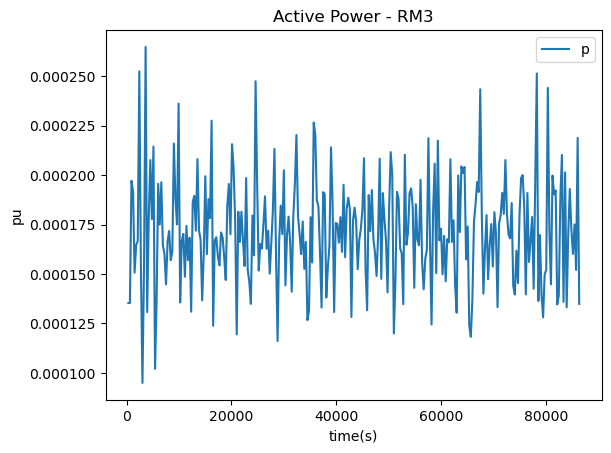

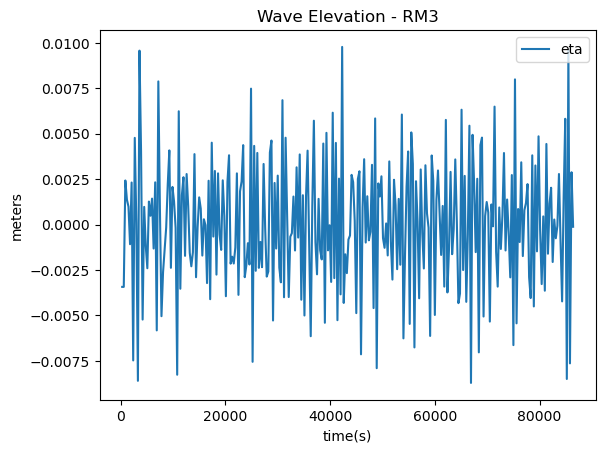

In [5]:
# WEC Device Data (RM3)
RM3_WEC = RM3_Farm_1.wec_devices[0]
print(RM3_WEC)
print(RM3_WEC.dataframe.head())

RM3_WEC.dataframe.plot("time", "p", title= "Active Power - RM3",ylabel='pu', xlabel='time(s)')
RM3_WEC.dataframe.plot("time", "eta", title= "Wave Elevation - RM3", ylabel='meters',xlabel='time(s)')

WECDevice:
    ├─ name: 'RM3_1_0'
    ├─ model: 'RM3'
    ├─ bus_location: 41
    ├─ sim_id: 1
    └─ rows: 288
    
                     time         p    q       eta
snapshots                                         
2025-09-06 00:00:00   300  0.000135  0.0 -0.003430
2025-09-06 00:05:00   600  0.000135  0.0 -0.003430
2025-09-06 00:10:00   900  0.000197  0.0  0.002427
2025-09-06 00:15:00  1200  0.000192  0.0  0.001373
2025-09-06 00:20:00  1500  0.000151  0.0  0.000987


<AxesSubplot:title={'center':'Wave Elevation'}, xlabel='time(s)', ylabel='meters'>

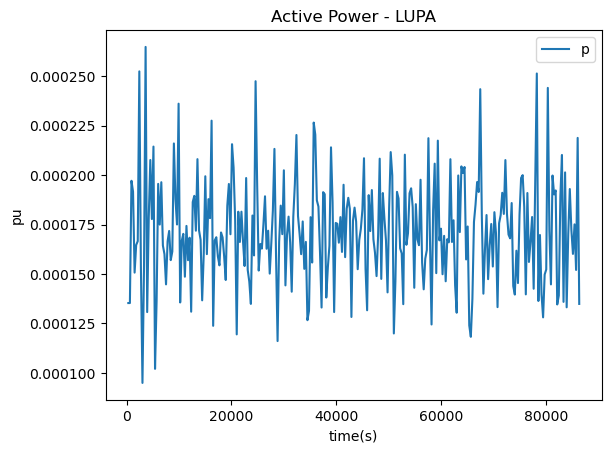

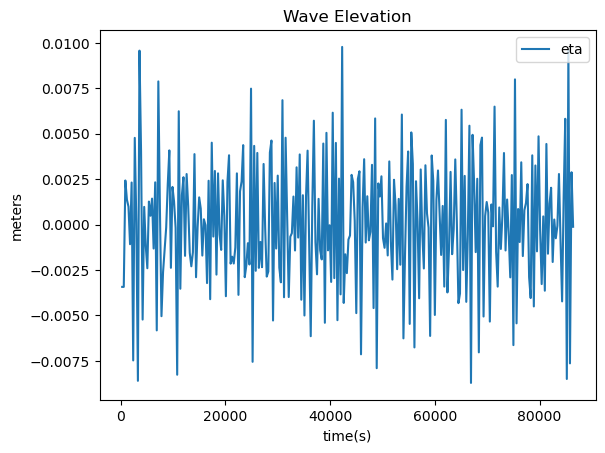

In [6]:
# WEC Device Data (RM3)
LUPA_WEC = LUPA_Farm_1.wec_devices[0]
print(LUPA_WEC)
print(LUPA_WEC.dataframe.head())

LUPA_WEC.dataframe.plot("time", "p", title= "Active Power - LUPA",ylabel='pu', xlabel='time(s)')
LUPA_WEC.dataframe.plot("time", "eta", title= "Wave Elevation", ylabel='meters',xlabel='time(s)')

---

## Review Grid data

In [7]:
grid = example3.pypsa.grid
grid

GridState:
├─ Components:
│   ├─ bus:   42 components
│   ├─ gen:   13 components
│   ├─ line:  37 components
│   └─ load:  31 components
├─ Case: IEEE 39 bus
└─ Modeler: pypsa

SLD Data Summary:
  Buses: 42
  Lines: 37
  Generators: 13
  Loads: 31


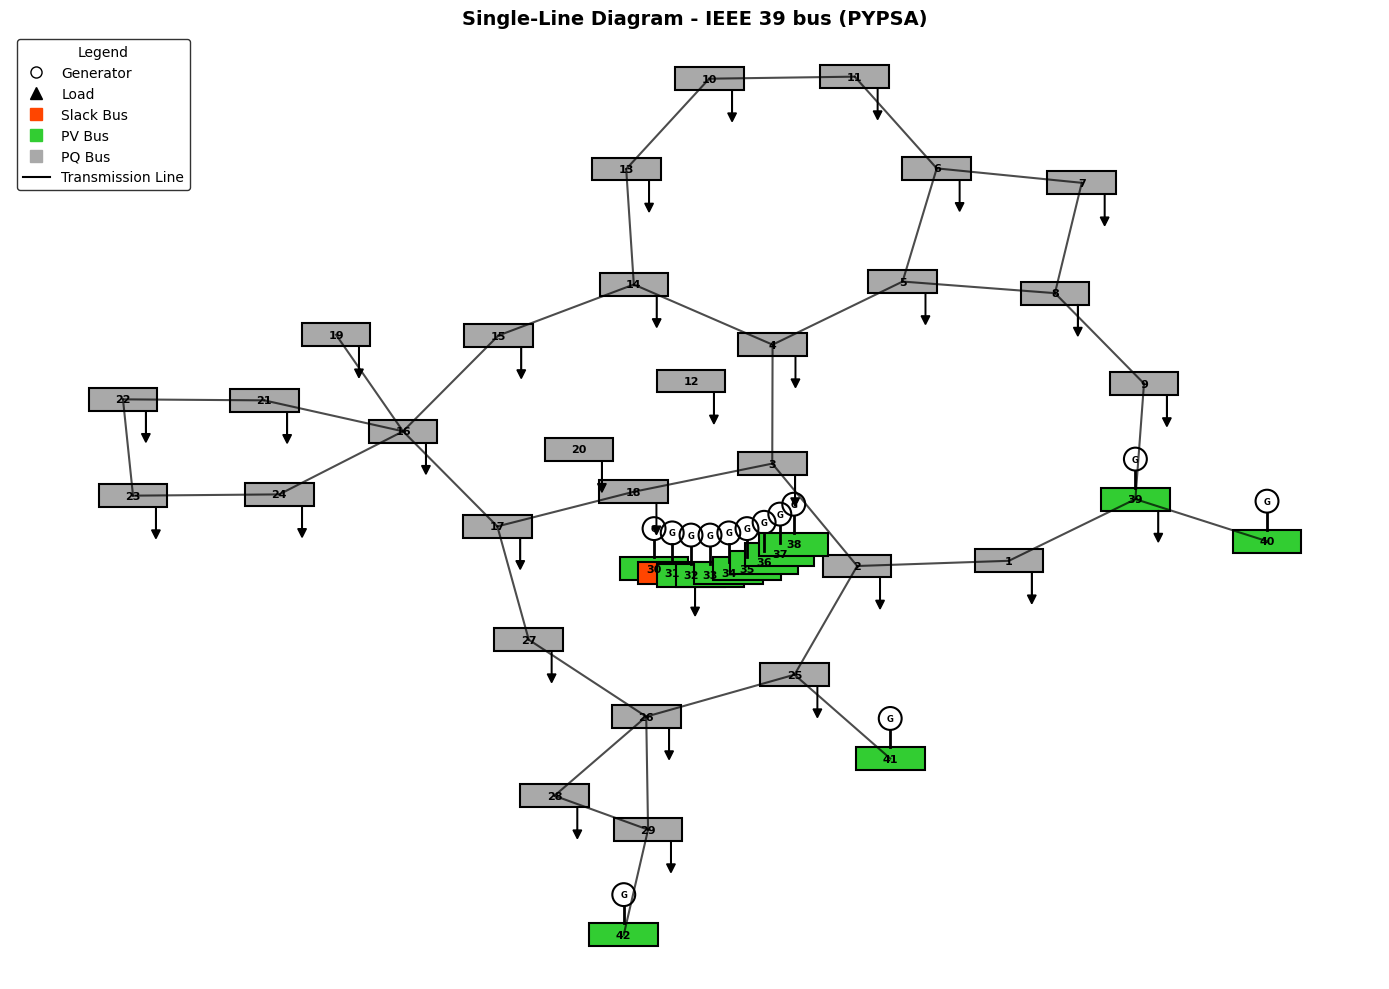

In [8]:
example3.plot.sld() # not working well for this case

<AxesSubplot:title={'center':'Load Curves for All Buses'}, xlabel='time', ylabel='pu'>

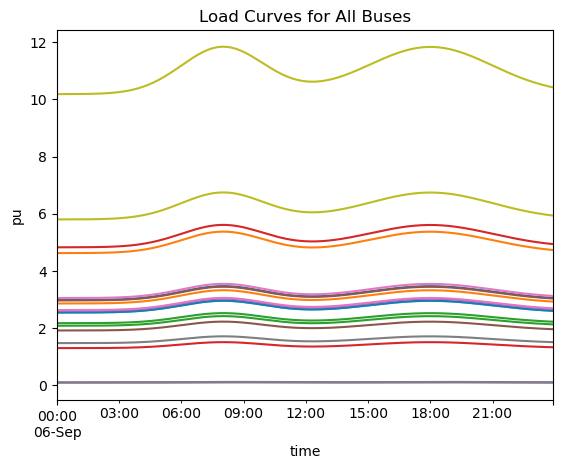

In [9]:
load_curves = example3.generate_load_curves()
load_curves.plot(ylabel='pu', title='Load Curves for All Buses', legend=False)

---

## Run Time Series Simulation

In [10]:
example3.simulate(load_curve=True) # takes some time!
example3.pypsa.report

PyPSA Simulating: 100%|██████████| 288/288 [02:08<00:00,  2.25step/s]


SolveReport:
├─ Converged: Successful
├─ Simulation Time: 128.13 s
├─ Num Steps: 288
├─ Case: IEEE 39 bus
└─ Modeler: pypsa

---

## Lets review our solve report first 

In [11]:
report = example3.pypsa.report.dataframe
report

,iter_time,converged,pf_solve_time,pf_solve_iter,snapshot_time,snapshot,message
0,0.638056,1,0.497432,4,0.140624,2025-09-06 00:00:00,converged
1,0.552840,1,0.370636,4,0.182204,2025-09-06 00:05:00,converged
2,0.415006,1,0.298036,4,0.101345,2025-09-06 00:10:00,converged
3,0.425851,1,0.269603,4,0.156248,2025-09-06 00:15:00,converged
4,0.587175,1,0.375640,4,0.195911,2025-09-06 00:20:00,converged
...,...,...,...,...,...,...,...
283,0.422492,1,0.281252,4,0.141240,2025-09-06 23:35:00,converged
284,0.422907,1,0.282283,4,0.140624,2025-09-06 23:40:00,converged
285,0.421876,1,0.296881,4,0.124995,2025-09-06 23:45:00,converged
286,0.449362,1,0.323901,4,0.125460,2025-09-06 23:50:00,converged


<AxesSubplot:xlabel='time', ylabel='iterations'>

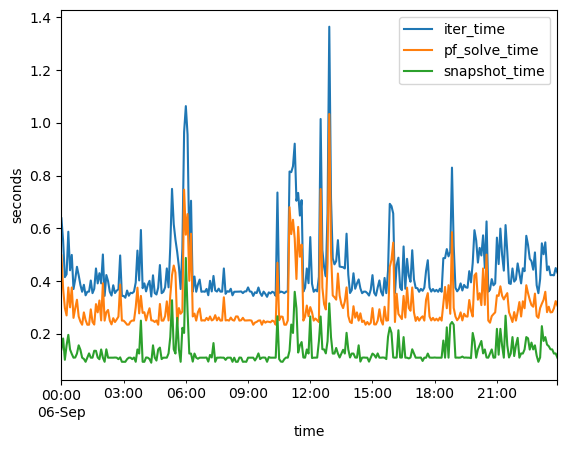

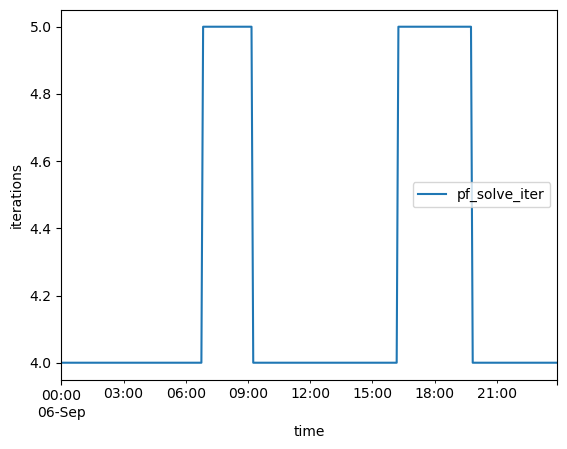

In [12]:
report.plot('snapshot', ['iter_time', 'pf_solve_time', 'snapshot_time'], xlabel='time', ylabel='seconds')
report.plot('snapshot', 'pf_solve_iter', xlabel='time', ylabel='iterations')

---

## Analyze and Visualize Results

Create comprehensive plots to analyze WEC performance and grid impact over time.

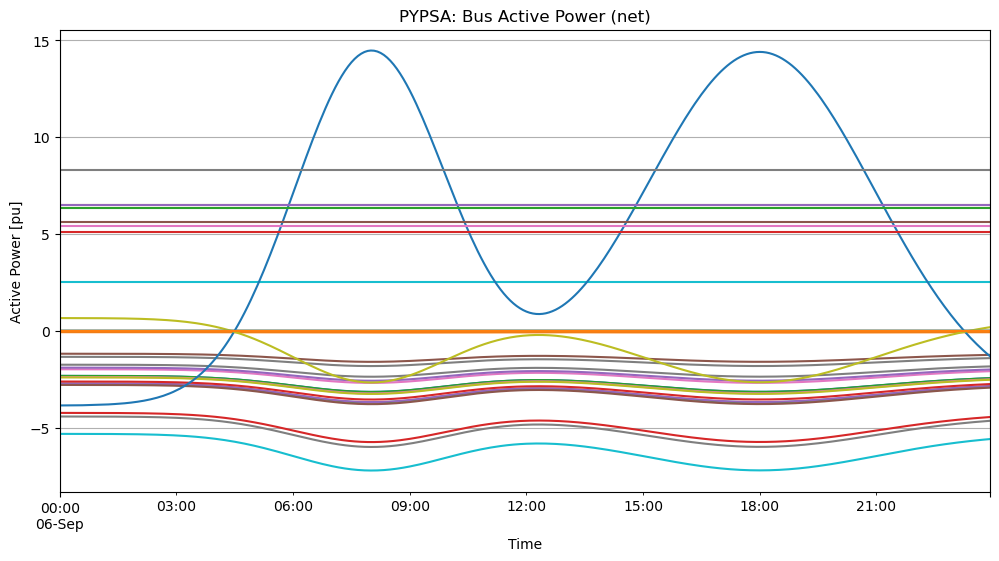

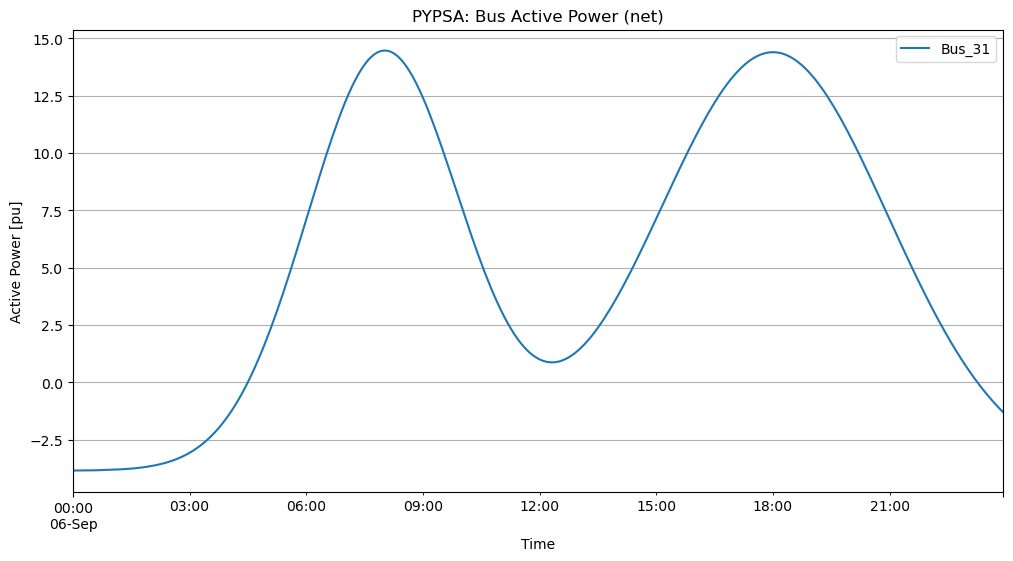

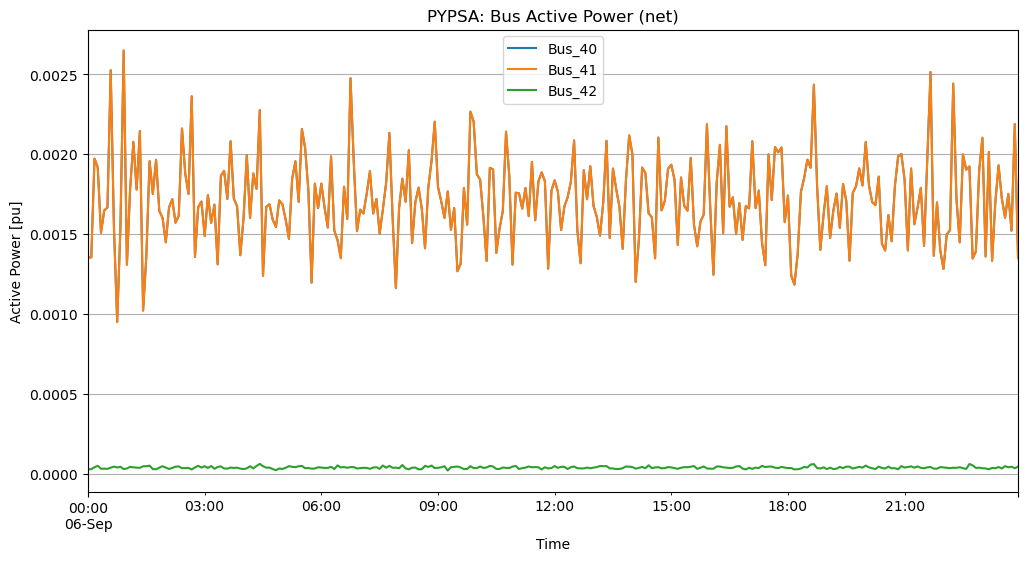

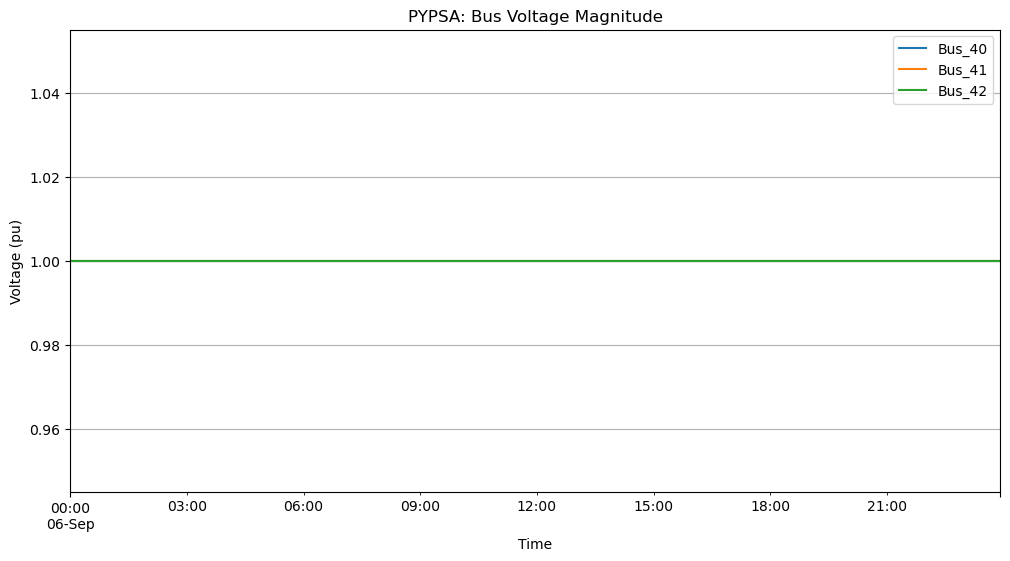

(<Figure size 1200x600 with 1 Axes>,
 <AxesSubplot:title={'center':'PYPSA: Bus Voltage Magnitude'}, xlabel='Time', ylabel='Voltage (pu)'>)

In [13]:
plot = example3.plot
plot.bus()
plot.bus(bus=['Bus_31']) # Swing Bus
plot.bus(bus=['Bus_40', 'Bus_41','Bus_42']) # WEC-Farm Buses
plot.bus(parameter='v_mag',bus=['Bus_40', 'Bus_41','Bus_42'])

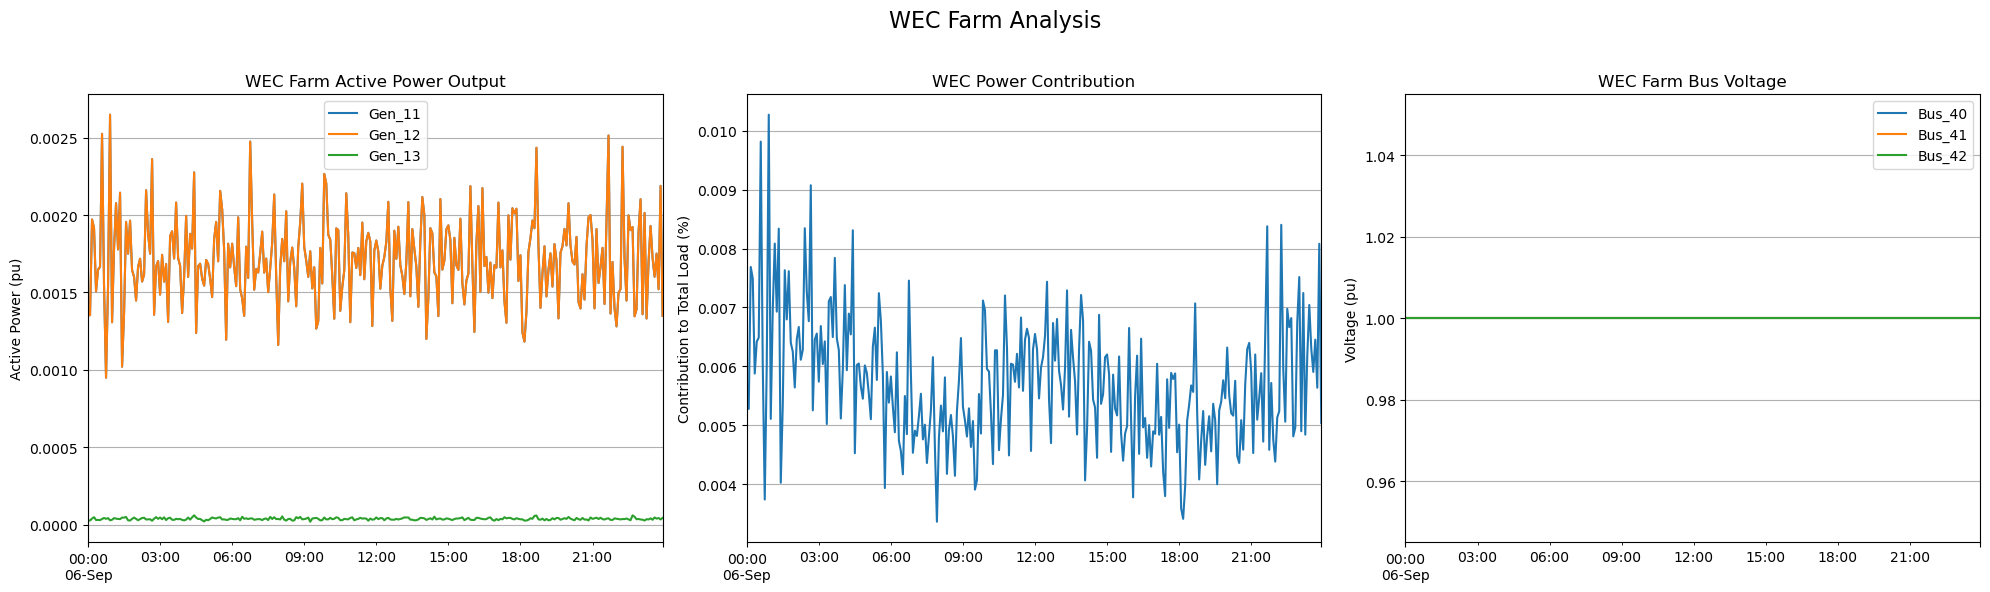

In [14]:
plot.wec_analysis()